In [1]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)


In [2]:
def f(x):
    """Inverse-logit"""
    return 1.0 / (1 + np.exp(-x))

def g(y):
    """Logit"""
    return np.log(y / (1.0 - y))

## 1. Logit-Normal Distribution

In [3]:
def pdf_normal(x):
    """Standard Normal PDF."""
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x**2)

def pdf_logistic(y):
    """PDF of Y = 1 / (1 + exp(-X)), X ~ N(0,1)."""
    x = g(y)
    return pdf_normal(x) * (1.0 / (y * (1.0 - y)))


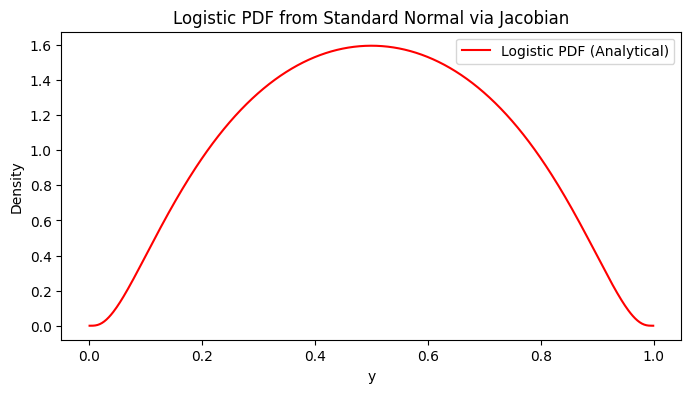

In [4]:
# Logistic PDF Plot
y_vals_logistic = np.linspace(0.001, 0.999, 500)  # Keep within (0,1)
pdf_logistic_vals = pdf_logistic(y_vals_logistic)

plt.figure(figsize=(8, 4))
plt.plot(y_vals_logistic, pdf_logistic_vals, label='Logistic PDF (Analytical)', color='red')
plt.title('Logistic PDF from Standard Normal via Jacobian')
plt.xlabel('y')
plt.ylabel('Density')
plt.legend()
plt.show()

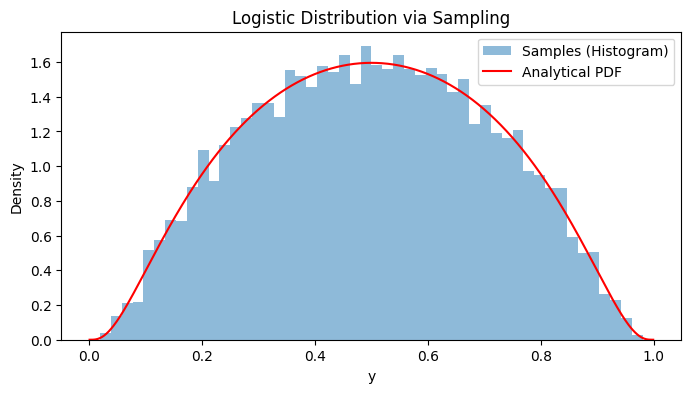

In [5]:
x_samples = np.random.randn(10_000)

# Transform: Y = 1 / (1 + exp(-X))
y_samples = f(x_samples)

# Plot histogram vs. analytical PDF
plt.figure(figsize=(8, 4))
plt.hist(y_samples, bins=50, density=True, alpha=0.5, label='Samples (Histogram)')
plt.plot(y_vals_logistic, pdf_logistic_vals, 'r-', label='Analytical PDF')
plt.title('Logistic Distribution via Sampling')
plt.xlabel('y')
plt.ylabel('Density')
plt.legend()
plt.show()

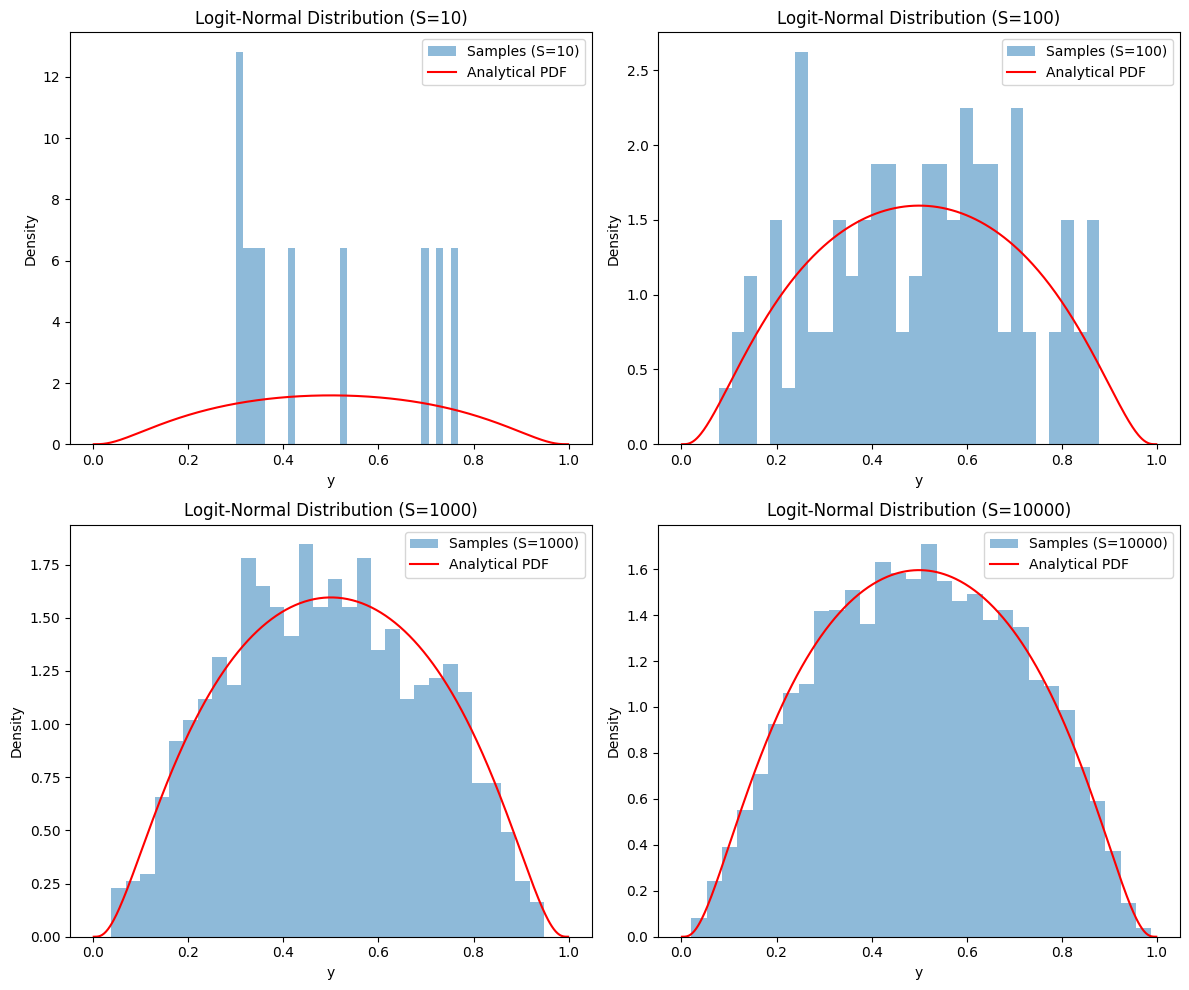

In [6]:
# Define sample sizes for the experiment
sample_sizes = [10, 100, 1000, 10000]

# Create a grid for y in the interval (0,1) for plotting the analytical PDF
y_vals = np.linspace(0.001, 0.999, 500)
pdf_vals = pdf_logistic(y_vals)

# Prepare subplots for part (d): multiple sample sizes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# To store MCSE values for part (e)
mcse_values = []

for i, S in enumerate(sample_sizes):
    # Sample from X ~ N(0,1)
    x_samples = np.random.randn(S)
    y_samples = f(x_samples)

    axes[i].hist(y_samples, bins=30, density=True, alpha=0.5, label=f'Samples (S={S})')
    # Overlay analytical PDF
    axes[i].plot(y_vals, pdf_vals, 'r-', label='Analytical PDF')
    axes[i].set_xlabel('y')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Logit-Normal Distribution (S={S})')
    axes[i].legend()

    # Compute MCSE for the estimate of the mean of Y
    sample_std = np.std(y_samples, ddof=1)
    mcse = sample_std / np.sqrt(S)
    mcse_values.append(mcse)

plt.tight_layout()
plt.show()

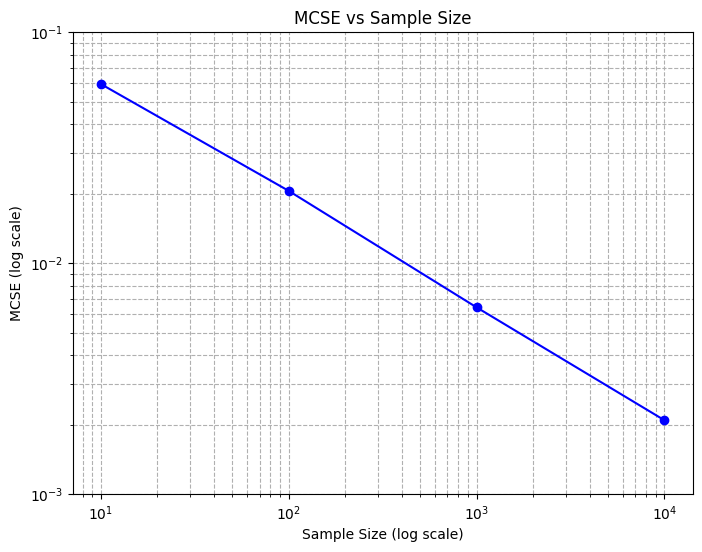

In [11]:
# Part (e): Plot MCSE vs sample size
plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, mcse_values, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.yticks([0.001, 0.01, 0.1])
plt.xlabel('Sample Size (log scale)')
plt.ylabel('MCSE (log scale)')
plt.title('MCSE vs Sample Size')
plt.grid(True, which="both", ls="--")
plt.show()

## 2. LCS Generators

In [8]:
def lcg(x, a, c, m):
    return (a * x + c) % m

def find_period_simple(a, c, m, x0):
    seen = []
    x = x0
    while x not in seen:
        seen.append(x)
        x = lcg(x, a, c, m)

    return len(seen), x


In [9]:
# m a power of 2
m = 2**4     # A small modulus (16)

# c and m are coprime
c = 3        # Increment

# a-1 divisible by all prime factors of m
# a-1 divisibble by 4 if m is divisible by 4
a = 5        # Multiplier

x0 = 3     # Seed

period, first_repeat = find_period_simple(a, c, m, x0)
print("The period of the LCG is:", period)
print("The first repeated value is:", first_repeat)

The period of the LCG is: 16
The first repeated value is: 3


https://en.wikipedia.org/wiki/Linear_congruential_generator#Parameters_in_common_use

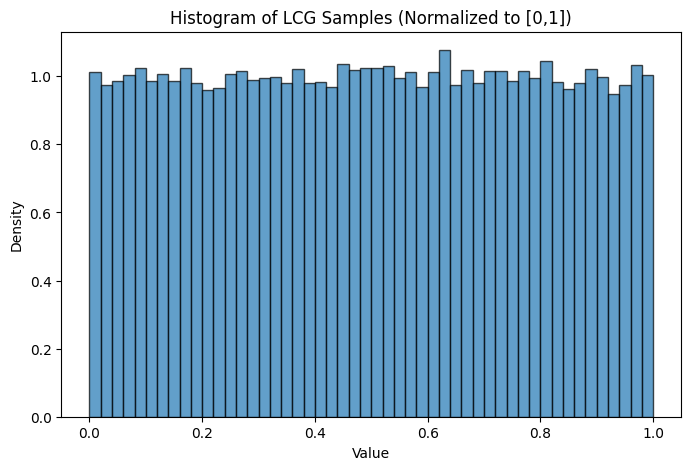

In [10]:
m = 2**32
a = 1_664_525
c = 1_013_904_223
seed = 156


N = 100_000  # total numbers to generate
x = seed
samples = []

for i in range(N):
    x = lcg(x, a, c, m)
    samples.append(x / m) # add normalized to samples


plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of LCG Samples (Normalized to [0,1])")
plt.show()
